In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import re
#from datetime import datetime
import datetime
from isoweek import Week

import pywt

def iso_week_to_date(iso_str):
    # Convert YYYY-Www into a date (Monday of that week)
    match = re.match(r"(\d{4})-W(\d{1,2})", iso_str)
    if not match:
        return None
    year, week = match.groups()
    year, week = int(year), int(week)
    return Week(year, week).monday()

def iso_week_to_fractional_year(yearweek):
    year = int(str(yearweek).split("-W")[0])
    week = int(str(yearweek).split("-W")[1])
    # date of the Monday of the given ISO week and year
    if week<53:
        monday_of_week = datetime.date.fromisocalendar(year, week, 1)
    else:
        monday_of_week = datetime.date.fromisocalendar(year, week-1, 7)
    # Get the first Monday of the year (ISO week 1)
    first_monday = datetime.date.fromisocalendar(year, 1, 1)
    
    # number of days since the first Monday of the year
    days_since_start = (monday_of_week - first_monday).days
    
    # fractional year
    total_days_in_year = 366 if monday_of_week.year % 4 == 0 else 365
    fractional_year = year + days_since_start / total_days_in_year
    return fractional_year

# Combined

0      1958.1283
1      1958.3818
2      1958.6235
3      1958.8983
4      1959.1298
         ...    
147    1994.8704
148    1995.1121
149    1995.3660
150    1995.6655
151    1995.8490
Name: time, Length: 152, dtype: float64
[1958.1283 1962.     1966.     1970.     1974.     1978.     1982.
 1986.     1990.     1994.    ]


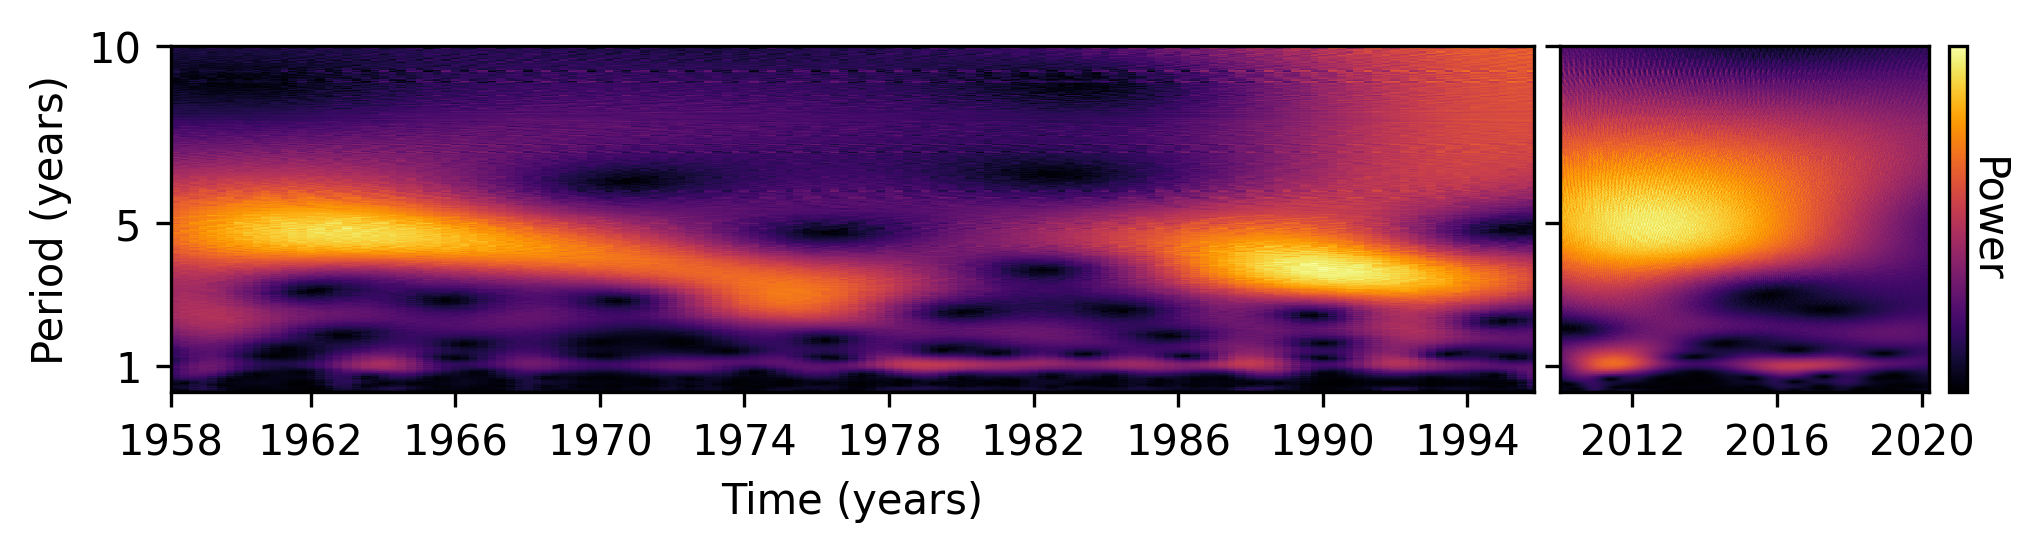

In [2]:
from matplotlib import gridspec

csvfile = 'data/DK_1958_1995_pseudofrac.csv'
eps_freq = 0.0000001

cmap = 'inferno'

fig = plt.figure(dpi=300)

fig.set_figheight(1.5)

fig.set_figwidth(9)

spec = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[3.7, 1], wspace=0.03,
                         hspace=0.5, height_ratios=[1])
ax0 = fig.add_subplot(spec[0])
ax1 = fig.add_subplot(spec[1])
axs = [ax0, ax1]

data = pd.read_csv(csvfile, dtype=float)

sqrt_transform = True

# Square root transform:
data["PseudoFrac"]
if sqrt_transform:
    pretransform_mean = data["PseudoFrac"].mean()
    data["PseudoFrac"] = np.sqrt(data["PseudoFrac"])
    data["PseudoFrac"] = data["PseudoFrac"] * pretransform_mean/data["PseudoFrac"].mean()

time = data['time']
chirp = data['PseudoFrac']

wavelet = "cmor1.5-1.0"

widths = np.linspace(1, 40, num=500)

sampling_period = np.diff(time).mean()
cwtmatr, freqs = pywt.cwt(chirp, widths, wavelet, sampling_period=sampling_period)
cwtmatr = np.abs(cwtmatr[:-1, :-1])


pcm = axs[0].pcolormesh(time, 1/(freqs+eps_freq), cwtmatr, cmap=cmap)
axs[0].set_xlabel("Time (years)")
axs[0].set_ylabel("Period (years)")
axs[0].set_yticks([1,5, 10])
xticks = np.arange(1958, 1995, 4.0)
print(time)
xticks[0] = time[0]
xlabels = [str(int(tick)) for tick in xticks]
print(xticks)
axs[0].set_xticks(xticks, labels=xlabels)

########## 2010-2025 ##########3
data = pd.read_csv("data/DK_2010_2025_posfrac.csv", dtype=str)

data["date"] = data["year_Week"].apply(iso_week_to_date)
data['date'] = pd.to_datetime(data["date"])

# Look only a pre-COVID times:
data = data[data["date"] < np.datetime64(iso_week_to_date("2020-W12"))]

data['time'] = data.apply(lambda row: iso_week_to_fractional_year(row['year_Week']), axis=1)

time = np.float64(data['time'])
chirp = np.float64(data['PosFrac'])

widths = np.linspace(1, 52*10, num=500)

sampling_period = np.diff(time).mean()
cwtmatr, freqs = pywt.cwt(chirp, widths, wavelet, sampling_period=sampling_period)
cwtmatr = np.abs(cwtmatr[:-1, :-1])

pcm = axs[1].pcolormesh(time, 1/(freqs+eps_freq), cwtmatr, cmap=cmap)
#axs[1].set_xlabel("Time (years)")
#axs[1].set_ylabel("Period")
axs[1].set_yticks([1,5, 10], labels=['','',''])
axs[1].set_ylim([0.25, 10])
axs[1].set_xticks([2012, 2016, 2020])

cbar = fig.colorbar(pcm, ax=axs, location='right', pad=0.01)
cbar.ax.set_yticks([])  
cbar.set_label("Power", rotation=270, labelpad=10)
